# Gas Turbine CO and NOx Emission — Robust Twoblock Example

The gas turbine dataset (Kaya et al., 2019, UCI ML Repository #551) contains 36,733 hourly readings 
from a gas turbine in a combined cycle power plant over 2011–2015. 

- **X** (9 variables): AT (ambient temp), AP (pressure), AH (humidity), AFDP (filter diff pressure), 
  GTEP (exhaust pressure), TIT (inlet temp), TAT (outlet temp), TEY (energy yield), CDP (compressor discharge pressure)
- **Y** (2 variables): CO and NOx emissions

This is a large-sample, moderate-dimension regression with naturally occurring outliers 
from operational anomalies. We compare twoblock and RTB with and without artificial contamination.
The `year` column is used to create a temporal train/test split (2011–2013 train, 2014–2015 test).

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from twoblock import twoblock, rtb
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 11, 'legend.fontsize': 10,
})

## Load data and temporal train/test split

In [2]:
df = pd.read_csv('../data/gas_turbine.csv')
print(f"Shape: {df.shape}")
print(f"Years: {sorted(df['year'].unique())}")

x_cols = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
y_cols = ['CO', 'NOX']
q = len(y_cols)

# Subsample for tractability
rng = np.random.default_rng(42)
df_sub = df.sample(n=5000, random_state=42).reset_index(drop=True)
X_all = df_sub[x_cols].values
Y_all = df_sub[y_cols].values
n = len(df_sub)
p = len(x_cols)
print(f"Subsampled: {n} cases, {p} X vars, {q} Y vars")

Shape: (36733, 12)
Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Subsampled: 5000 cases, 9 X vars, 2 Y vars


## Identify outliers via tolerance ellipse on (CO, NOx)

Tolerance ellipse cutoff (chi2, 97.5%): 7.38
Inliers: 3908, Outliers: 1092 (21.8%)


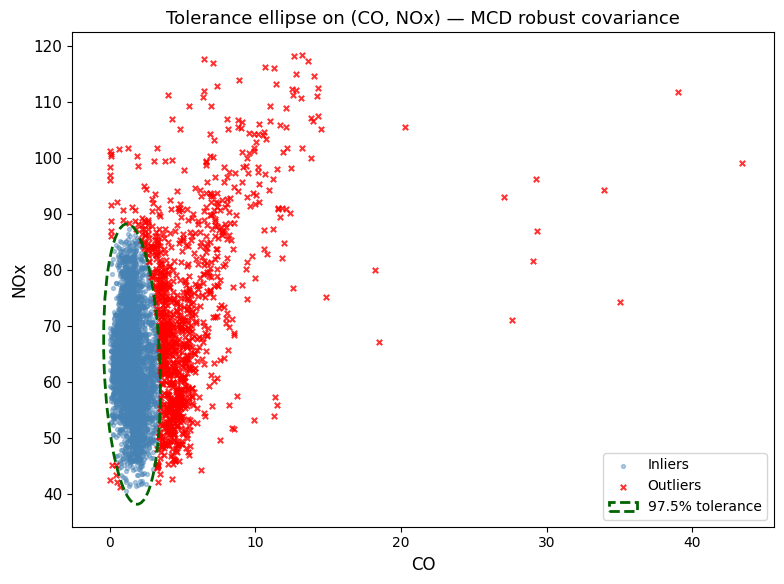

In [3]:
from scipy.stats import chi2
from sklearn.covariance import MinCovDet
from matplotlib.patches import Ellipse

# Fit robust covariance (MCD) to Y for tolerance ellipse
mcd = MinCovDet(random_state=42).fit(Y_all)
mahal_dist = mcd.mahalanobis(Y_all)

# 97.5% tolerance ellipse (chi2 with q=2 dof)
cutoff = chi2.ppf(0.975, df=q)
is_inlier = mahal_dist <= cutoff

n_outliers_natural = np.sum(~is_inlier)
print(f"Tolerance ellipse cutoff (chi2, 97.5%): {cutoff:.2f}")
print(f"Inliers: {np.sum(is_inlier)}, Outliers: {n_outliers_natural} ({n_outliers_natural/n:.1%})")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Y_all[is_inlier, 0], Y_all[is_inlier, 1], s=8, alpha=0.4, label='Inliers', color='steelblue')
ax.scatter(Y_all[~is_inlier, 0], Y_all[~is_inlier, 1], s=15, alpha=0.8, label='Outliers', color='red', marker='x')

# Draw ellipse correctly using eigendecomposition of MCD covariance
cov = mcd.covariance_
loc = mcd.location_
eigvals, eigvecs = np.linalg.eigh(cov)
# Sort by largest eigenvalue
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Angle of the first eigenvector
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
# Width and height = 2 * sqrt(eigenvalue * chi2_cutoff)
width = 2 * np.sqrt(eigvals[0] * cutoff)
height = 2 * np.sqrt(eigvals[1] * cutoff)

ell = Ellipse(xy=loc, width=width, height=height, angle=angle,
              edgecolor='darkgreen', facecolor='none', linewidth=2, linestyle='--', label='97.5% tolerance')
ax.add_patch(ell)

ax.set_xlabel('CO'); ax.set_ylabel('NOx')
ax.set_title('Tolerance ellipse on (CO, NOx) — MCD robust covariance')
ax.legend()
plt.tight_layout()
plt.show()

## Build clean/contaminated train and clean test sets

In [4]:
# Split inliers into 70% train / 30% test
inlier_idx = np.where(is_inlier)[0]
outlier_idx = np.where(~is_inlier)[0]

rng.shuffle(inlier_idx)
n_train_clean = int(0.7 * len(inlier_idx))
train_clean_idx = inlier_idx[:n_train_clean]
test_clean_idx = inlier_idx[n_train_clean:]

X_train_clean = X_all[train_clean_idx]
Y_train_clean = Y_all[train_clean_idx]
X_test = X_all[test_clean_idx]
Y_test = Y_all[test_clean_idx]

# Ensure contaminated set contains outliers extreme in BOTH CO and NOx
# Target: ~10% contamination rate
n_outliers_inject = int(0.10 * n_train_clean / (1 - 0.10))  # so that inject/(clean+inject) ≈ 10%
n_outliers_inject = min(n_outliers_inject, len(outlier_idx))

# Rank outliers by how extreme they are in each variable
outlier_Y = Y_all[outlier_idx]
co_rank = np.argsort(np.abs(outlier_Y[:, 0] - mcd.location_[0]))[::-1]
nox_rank = np.argsort(np.abs(outlier_Y[:, 1] - mcd.location_[1]))[::-1]

# Take top 25% most extreme in CO, top 25% in NOx, fill rest randomly
n_per_type = max(n_outliers_inject // 4, 5)

co_extreme = outlier_idx[co_rank[:n_per_type]]
nox_extreme = outlier_idx[nox_rank[:n_per_type]]
forced = np.union1d(co_extreme, nox_extreme)
remaining = np.setdiff1d(outlier_idx, forced)
n_random = max(0, n_outliers_inject - len(forced))
if n_random > 0 and len(remaining) > 0:
    random_fill = rng.choice(remaining, min(n_random, len(remaining)), replace=False)
    inject_idx = np.concatenate([forced, random_fill])[:n_outliers_inject]
else:
    inject_idx = forced[:n_outliers_inject]

X_train_contam = np.vstack([X_train_clean, X_all[inject_idx]])
Y_train_contam = np.vstack([Y_train_clean, Y_all[inject_idx]])
is_outlier_contam = np.array([False] * len(train_clean_idx) + [True] * len(inject_idx))
n_train_contam = len(X_train_contam)
n_outliers_inject = len(inject_idx)

# Verify coverage
injected_Y = Y_all[inject_idx]
co_range = (injected_Y[:, 0].min(), injected_Y[:, 0].max())
nox_range = (injected_Y[:, 1].min(), injected_Y[:, 1].max())

print(f"Clean train:        {X_train_clean.shape[0]} cases (all inliers)")
print(f"Contaminated train: {n_train_contam} cases ({len(train_clean_idx)} clean + {n_outliers_inject} outliers)")
print(f"Clean test:         {X_test.shape[0]} cases (all inliers)")
print(f"Contamination rate: {n_outliers_inject / n_train_contam:.1%}")
print(f"\nInjected outlier CO range:  [{co_range[0]:.1f}, {co_range[1]:.1f}]")
print(f"Injected outlier NOx range: [{nox_range[0]:.1f}, {nox_range[1]:.1f}]")
print(f"  includes {len(co_extreme)} CO-extreme + {len(nox_extreme)} NOx-extreme (overlap: {len(np.intersect1d(co_extreme, nox_extreme))})")

Clean train:        2735 cases (all inliers)
Contaminated train: 3038 cases (2735 clean + 303 outliers)
Clean test:         1173 cases (all inliers)
Contamination rate: 10.0%

Injected outlier CO range:  [0.0, 43.4]
Injected outlier NOx range: [42.1, 118.5]
  includes 75 CO-extreme + 75 NOx-extreme (overlap: 35)


## Cross-validate and evaluate all methods

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

neg_mse = make_scorer(mean_squared_error, greater_is_better=False)

# Weights for weighted average MSE: inverse of Y variance (so both responses contribute equally)
y_var = np.var(Y_all, axis=0)
w_mse = (1.0 / y_var) / np.sum(1.0 / y_var)
print(f"Y variances: CO={y_var[0]:.2f}, NOx={y_var[1]:.2f}")
print(f"MSE weights: CO={w_mse[0]:.3f}, NOx={w_mse[1]:.3f}")

def weighted_mean_mse(mse_list):
    return np.average(mse_list, weights=w_mse)

def fit_and_eval(X_tr, Y_tr, X_te, Y_te, label):
    """Fit all methods with CV for twoblock hyperparams, evaluate on test."""
    results = {}
    
    # PLS2 (CV n_components)
    gcv_pls = GridSearchCV(PLSRegression(), {'n_components': [3, 5, 7, 9], 'scale': [True]},
                           scoring=neg_mse, cv=5)
    gcv_pls.fit(X_tr, Y_tr)
    Yp = gcv_pls.predict(X_te)
    results['PLS2'] = [mean_squared_error(Y_te[:, i], Yp[:, i]) for i in range(q)]
    print(f"  PLS2 best: {gcv_pls.best_params_}")
    
    # Twoblock dense (CV)
    gcv_tb = GridSearchCV(twoblock(verbose=False, copy=True),
                          {'n_components_x': [5, 7, 9, 11], 'n_components_y': [1, 2],
                           'scale': ['std', 'None']},
                          scoring=neg_mse, cv=5)
    gcv_tb.fit(X_tr, Y_tr)
    Yp = gcv_tb.predict(X_te)
    results['TB dense'] = [mean_squared_error(Y_te[:, i], Yp[:, i]) for i in range(q)]
    print(f"  TB dense best: {gcv_tb.best_params_}")
    
    # Twoblock sparse (CV)
    gcv_tbs = GridSearchCV(twoblock(verbose=False, copy=True),
                           {'n_components_x': [5, 7, 9, 11], 'n_components_y': [1, 2],
                            'sparse': [True], 'eta_x': [0.3, 0.5, 0.7], 'eta_y': [0],
                            'scale': ['std','None']},
                           scoring=neg_mse, cv=5)
    gcv_tbs.fit(X_tr, Y_tr)
    Yp = gcv_tbs.predict(X_te)
    results['TB sparse'] = [mean_squared_error(Y_te[:, i], Yp[:, i]) for i in range(q)]
    print(f"  TB sparse best: {gcv_tbs.best_params_}")
    
    # RTB dense (CV)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gcv_rtb = GridSearchCV(rtb(verbose=False, copy=True),
                               {'n_components_x': [5, 7, 9, 11], 'n_components_y': [1, 2],
                                'scale': ['mad', 'None'],
                                'probp1': [0.75], 'probp2': [0.90], 'probp3': [0.95]},
                               scoring=neg_mse, cv=5, error_score=np.nan)
        gcv_rtb.fit(X_tr, Y_tr)
    Yp = gcv_rtb.predict(X_te)
    results['RTB dense'] = [mean_squared_error(Y_te[:, i], Yp[:, i]) for i in range(q)]
    print(f"  RTB dense best: {gcv_rtb.best_params_}")
    
    # RTB sparse (CV)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gcv_rtbs = GridSearchCV(rtb(verbose=False, copy=True),
                                {'n_components_x': [5, 7, 9, 11], 'n_components_y': [1, 2],
                                 'sparse': [True], 'eta_x': [0.3, 0.5, 0.7], 'eta_y': [0],
                                 'scale': ['mad','None'],
                                 'probp1': [0.75], 'probp2': [0.90], 'probp3': [0.95]},
                                scoring=neg_mse, cv=5, error_score=np.nan)
        gcv_rtbs.fit(X_tr, Y_tr)
    Yp = gcv_rtbs.predict(X_te)
    results['RTB sparse'] = [mean_squared_error(Y_te[:, i], Yp[:, i]) for i in range(q)]
    print(f"  RTB sparse best: {gcv_rtbs.best_params_}")
    
    summary = pd.DataFrame(results, index=y_cols).T
    summary['Weighted Mean'] = [weighted_mean_mse(results[m]) for m in results]
    print(f"\n=== {label} ===")
    display(summary.round(3))
    return results, gcv_rtb, gcv_rtbs

Y variances: CO=5.67, NOx=134.76
MSE weights: CO=0.960, NOx=0.040


## Scenario 1: Clean training data

In [6]:
results_clean, _, _ = fit_and_eval(X_train_clean, Y_train_clean, X_test, Y_test, "Clean train")

  PLS2 best: {'n_components': 9, 'scale': True}
  TB dense best: {'n_components_x': 9, 'n_components_y': 2, 'scale': 'std'}
  TB sparse best: {'eta_x': 0.5, 'eta_y': 0, 'n_components_x': 9, 'n_components_y': 2, 'scale': 'std', 'sparse': True}
  RTB dense best: {'n_components_x': 9, 'n_components_y': 2, 'probp1': 0.75, 'probp2': 0.9, 'probp3': 0.95, 'scale': 'None'}
  RTB sparse best: {'eta_x': 0.3, 'eta_y': 0, 'n_components_x': 9, 'n_components_y': 2, 'probp1': 0.75, 'probp2': 0.9, 'probp3': 0.95, 'scale': 'None', 'sparse': True}

=== Clean train ===


,CO,NOX,Weighted Mean
PLS2,0.338,31.648,1.602
TB dense,0.338,31.648,1.602
TB sparse,0.338,31.648,1.602
RTB dense,0.338,31.632,1.602
RTB sparse,0.338,31.632,1.602


## Scenario 2: Contaminated training (clean + natural outliers)

  PLS2 best: {'n_components': 9, 'scale': True}
  TB dense best: {'n_components_x': 5, 'n_components_y': 2, 'scale': 'None'}
  TB sparse best: {'eta_x': 0.5, 'eta_y': 0, 'n_components_x': 5, 'n_components_y': 2, 'scale': 'None', 'sparse': True}
  RTB dense best: {'n_components_x': 7, 'n_components_y': 1, 'probp1': 0.75, 'probp2': 0.9, 'probp3': 0.95, 'scale': 'None'}
  RTB sparse best: {'eta_x': 0.5, 'eta_y': 0, 'n_components_x': 5, 'n_components_y': 2, 'probp1': 0.75, 'probp2': 0.9, 'probp3': 0.95, 'scale': 'None', 'sparse': True}

=== Contaminated train ===


,CO,NOX,Weighted Mean
PLS2,1.041,48.258,2.948
TB dense,1.057,59.610,3.421
TB sparse,1.103,58.898,3.436
RTB dense,0.619,37.445,2.106
RTB sparse,0.373,41.274,2.025


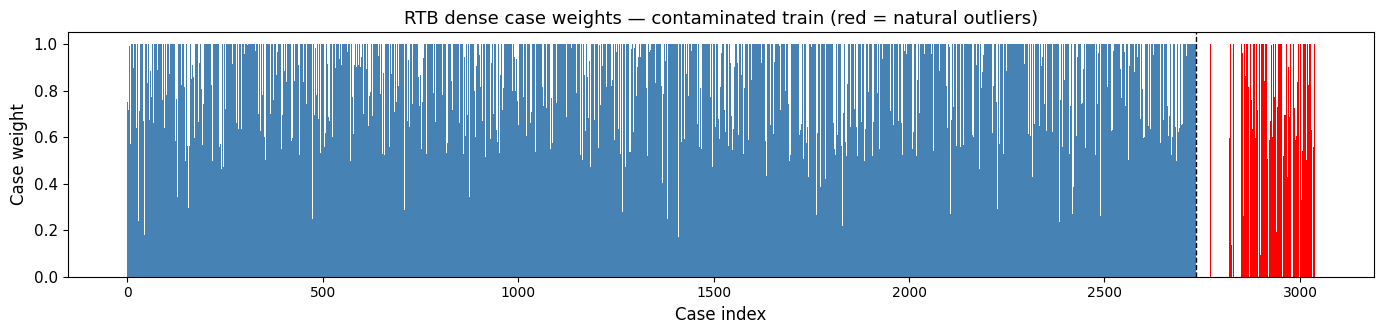

Outliers downweighted: 138/303 (46%)


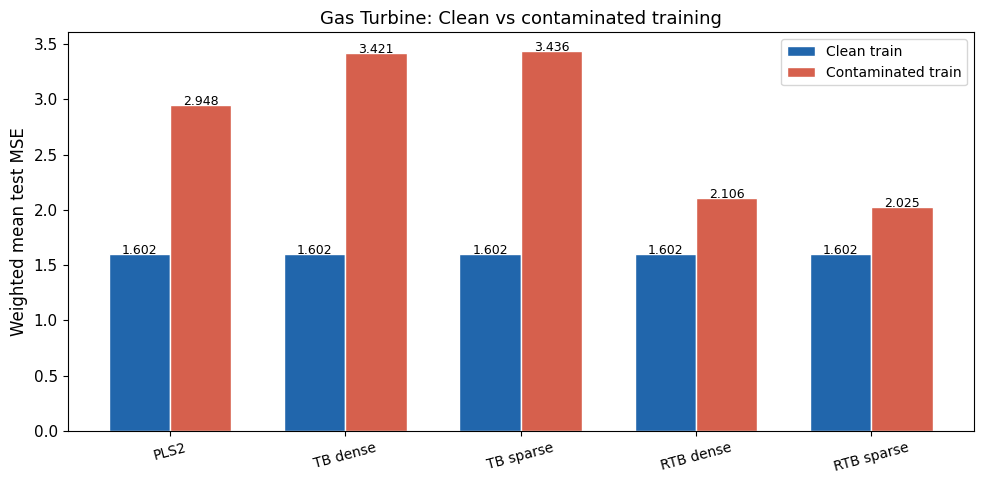

In [7]:
results_contam, gcv_rtb_contam, gcv_rtbs_contam = fit_and_eval(
    X_train_contam, Y_train_contam, X_test, Y_test, "Contaminated train"
)

# Case weights
fig, ax = plt.subplots(figsize=(14, 3.5))
colors_cw = ['red' if is_outlier_contam[i] else 'steelblue' for i in range(n_train_contam)]
ax.bar(range(n_train_contam), gcv_rtb_contam.best_estimator_.caseweights_, color=colors_cw, width=1)
ax.set_xlabel('Case index'); ax.set_ylabel('Case weight')
ax.set_title('RTB dense case weights — contaminated train (red = natural outliers)')
ax.axvline(len(train_clean_idx) - 0.5, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

n_dw = np.sum(gcv_rtb_contam.best_estimator_.caseweights_[is_outlier_contam] < 0.5)
print(f"Outliers downweighted: {n_dw}/{n_outliers_inject} ({n_dw/n_outliers_inject:.0%})")

# Summary comparison with weighted mean MSE
methods = list(results_clean.keys())
wmean_clean = [weighted_mean_mse(results_clean[m]) for m in methods]
wmean_contam = [weighted_mean_mse(results_contam[m]) for m in methods]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, wmean_clean, width, label='Clean train', color='#2166ac', edgecolor='white')
ax.bar(x + width/2, wmean_contam, width, label='Contaminated train', color='#d6604d', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel('Weighted mean test MSE'); ax.set_title('Gas Turbine: Clean vs contaminated training')
ax.legend()
for i, (vc, vo) in enumerate(zip(wmean_clean, wmean_contam)):
    ax.text(i - width/2, vc + 0.002, "{:.3f}".format(vc), ha='center', fontsize=9)
    ax.text(i + width/2, vo + 0.002, "{:.3f}".format(vo), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
## Variable selection by RTB sparse

RTB sparse: 9/9 X variables retained
Retained: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
Eliminated: []


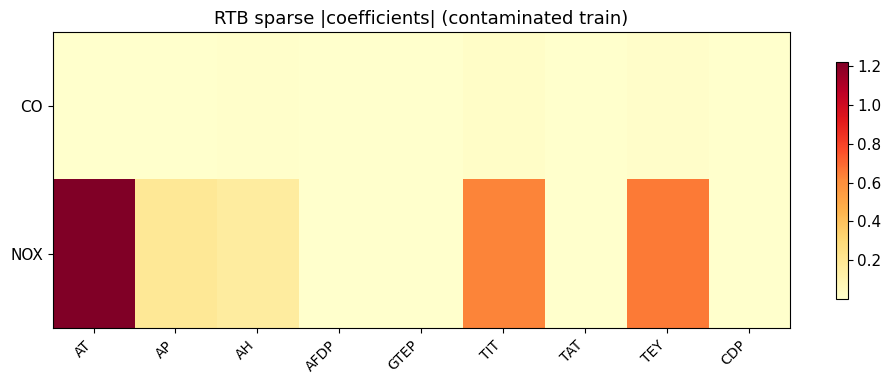

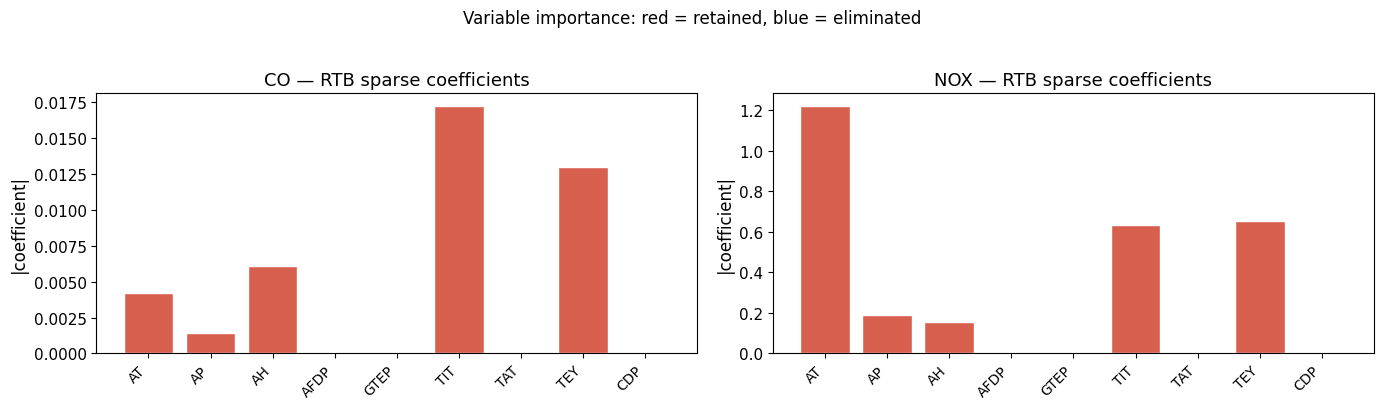

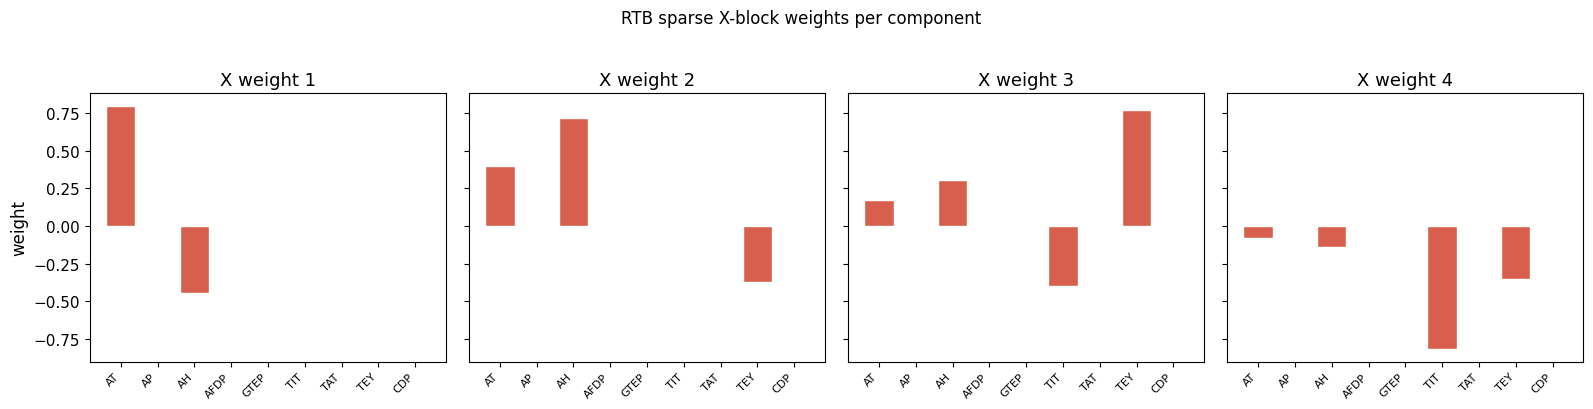

In [9]:
# Examine coefficient matrix from RTB sparse on contaminated data
best_rtbs = gcv_rtbs_contam.best_estimator_
B = best_rtbs.coef_  # (p, q)

# Variable is retained if any coefficient across Y columns exceeds threshold
tol = 1e-8
retained = np.any(np.abs(B) > tol, axis=1)
n_retained = np.sum(retained)

print(f"RTB sparse: {n_retained}/{p} X variables retained")
print(f"Retained: {[x_cols[i] for i in range(p) if retained[i]]}")
print(f"Eliminated: {[x_cols[i] for i in range(p) if not retained[i]]}")

# Coefficient heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(np.abs(B).T, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(p))
ax.set_xticklabels(x_cols, rotation=45, ha='right')
ax.set_yticks(range(q))
ax.set_yticklabels(y_cols)
ax.set_title('RTB sparse |coefficients| (contaminated train)')
plt.colorbar(im, ax=ax, shrink=0.8)

# Mark eliminated variables
for j in range(p):
    if not retained[j]:
        ax.axvline(j, color='blue', linewidth=2, alpha=0.5)
        ax.text(j, -0.6, 'X', ha='center', va='center', color='blue', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Bar chart of coefficient magnitudes per X variable
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for j, yname in enumerate(y_cols):
    ax = axes[j]
    coefs = B[:, j]
    colors = ['#d6604d' if np.abs(coefs[i]) > tol else '#92c5de' for i in range(p)]
    ax.bar(range(p), np.abs(coefs), color=colors, edgecolor='white')
    ax.set_xticks(range(p))
    ax.set_xticklabels(x_cols, rotation=45, ha='right')
    ax.set_ylabel('|coefficient|')
    ax.set_title(f'{yname} — RTB sparse coefficients')

fig.suptitle('Variable importance: red = retained, blue = eliminated', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# X-block weights per component
W = best_rtbs.x_weights_
n_comp_sel = W.shape[1]
fig, axes = plt.subplots(1, min(n_comp_sel, 4), figsize=(4 * min(n_comp_sel, 4), 4), sharey=True)
if n_comp_sel == 1:
    axes = [axes]
for k in range(min(n_comp_sel, 4)):
    ax = axes[k]
    w = W[:, k]
    colors = ['#d6604d' if np.abs(w[i]) > tol else '#92c5de' for i in range(p)]
    ax.bar(range(p), w, color=colors, edgecolor='white')
    ax.set_xticks(range(p))
    ax.set_xticklabels(x_cols, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'X weight {k+1}')
    if k == 0:
        ax.set_ylabel('weight')

fig.suptitle('RTB sparse X-block weights per component', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

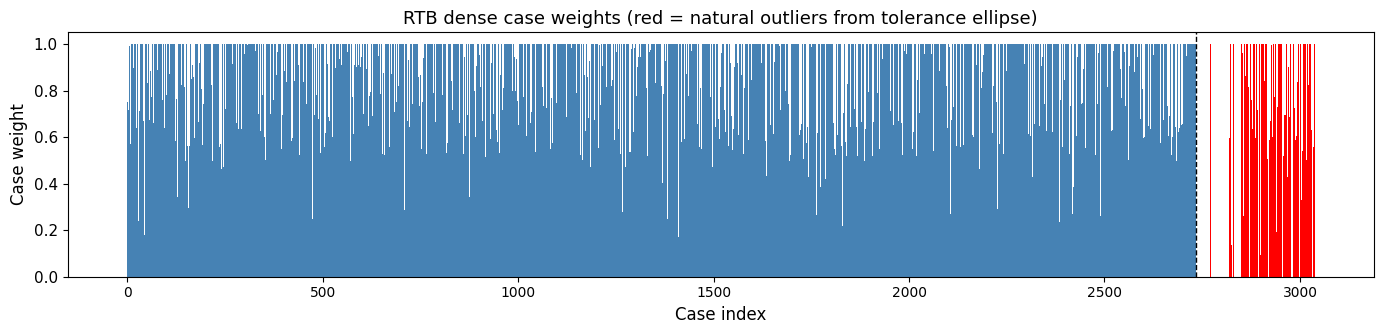

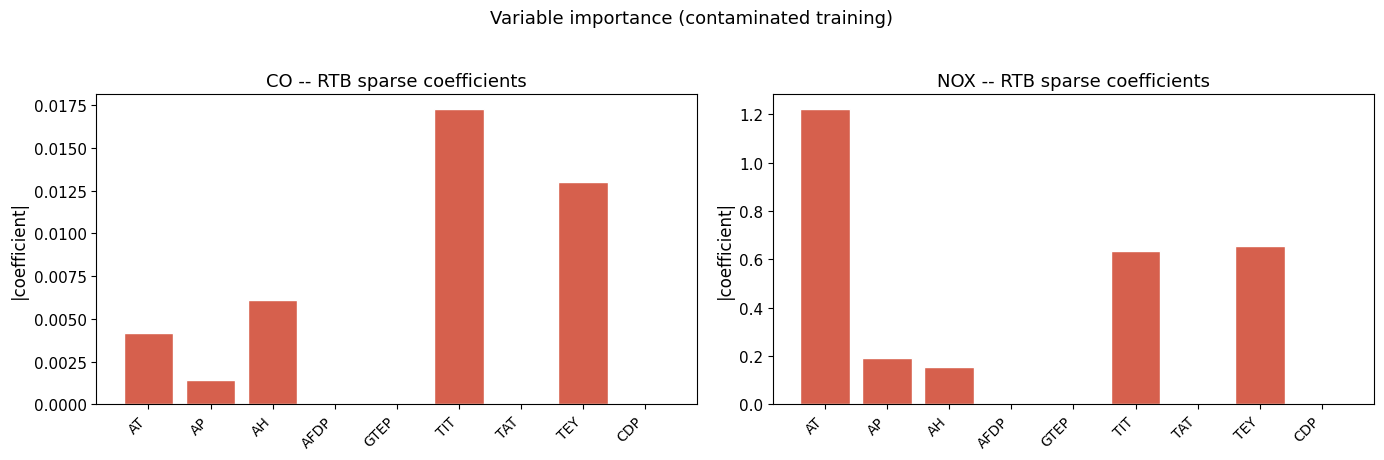

Figures exported to ../../twoblock_rtb_paper/


In [12]:
## Export figures for paper

import os
fig_dir = '../../twoblock_rtb_paper'
os.makedirs(fig_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 3.5))
colors_cw = ['red' if is_outlier_contam[i] else 'steelblue' for i in range(n_train_contam)]
ax.bar(range(n_train_contam), gcv_rtb_contam.best_estimator_.caseweights_, color=colors_cw, width=1)
ax.set_xlabel('Case index')
ax.set_ylabel('Case weight')
ax.set_title('RTB dense case weights (red = natural outliers from tolerance ellipse)')
ax.axvline(len(train_clean_idx) - 0.5, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'gas_turbine_caseweights.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# RTB sparse coefficient bar charts
B = gcv_rtbs_contam.best_estimator_.coef_
tol = 1e-8
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for j, yname in enumerate(y_cols):
    ax = axes[j]
    coefs = B[:, j]
    colors = ['#d6604d' if np.abs(coefs[i]) > tol else '#92c5de' for i in range(p)]
    ax.bar(range(p), np.abs(coefs), color=colors, edgecolor='white')
    ax.set_xticks(range(p))
    ax.set_xticklabels(x_cols, rotation=45, ha='right')
    ax.set_ylabel('|coefficient|')
    ax.set_title('{} -- RTB sparse coefficients'.format(yname))
fig.suptitle('Variable importance (contaminated training)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'gas_turbine_rtb_sparse_coefs.pdf'), bbox_inches='tight', dpi=300)
plt.show()

print("Figures exported to {}/".format(fig_dir))